In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

In [2]:
df = pd.read_csv("../data/conversion_data.csv")

df.head()

,User_ID,Group,Converted
0,1,A,0
1,2,B,0
2,3,A,0
3,4,A,0
4,5,A,0


# A/B Testing Analysis for Website Conversion Optimization

## Problem Statement

An e-commerce company introduced a new version of its website's **Buy Now** button to improve customer conversions.

The goal of this analysis is to determine whether the new design (Version B) leads to a statistically significant increase in the conversion rate compared to the old design (Version A).

Using A/B testing and hypothesis testing, we will evaluate whether the observed difference is significant enough to recommend implementing Version B for all users.

In [3]:
# Display the first five rows
df.head()


,User_ID,Group,Converted
0,1,A,0
1,2,B,0
2,3,A,0
3,4,A,0
4,5,A,0


In [4]:
# Display the last five rows
df.tail()


,User_ID,Group,Converted
9995,9996,B,0
9996,9997,A,0
9997,9998,B,0
9998,9999,B,0
9999,10000,A,0


In [5]:
# Shape of the dataset
df.shape

(10000, 3)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   User_ID    10000 non-null  int64
 1   Group      10000 non-null  str  
 2   Converted  10000 non-null  int64
dtypes: int64(2), str(1)
memory usage: 234.5 KB


### What I Observed

The dataset contains information for 10,000 users.

There are three columns, and all of them have complete data. Since there are no missing values, the dataset is ready for analysis without any preprocessing.

In [7]:
df.isnull().sum()


User_ID      0
Group        0
Converted    0
dtype: int64

## About the Dataset

The dataset contains information from an A/B test conducted on a website.

Each user was randomly assigned to one of two groups:

- **Group A** – Users who saw the original website design
- **Group B** – Users who saw the new website design

The dataset also records whether each user completed a purchase.


In [8]:
df.duplicated().sum()

np.int64(0)

### Dataset Columns

- **User_ID:** A unique ID assigned to every user.
- **Group:** Indicates whether the user belongs to Group A or Group B.
- **Converted:** Shows whether the user made a purchase.
  - **1** means the user converted.
  - **0** means the user did not convert.

In [9]:
df.describe()


,User_ID,Converted
count,10000.00000,10000.00000
mean,5000.50000,0.13050
std,2886.89568,0.33687
min,1.00000,0.00000
25%,2500.75000,0.00000
50%,5000.50000,0.00000
75%,7500.25000,0.00000
max,10000.00000,1.00000


In [10]:
df["Group"].value_counts()


Group
A    5013
B    4987
Name: count, dtype: int64

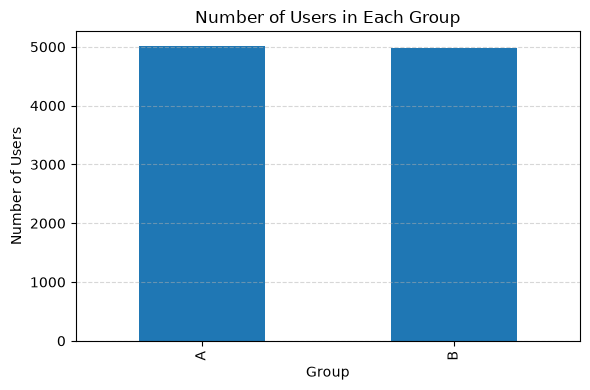

In [26]:
group_counts = df["Group"].value_counts()

plt.figure(figsize=(6,4))
group_counts.plot(kind="bar")

plt.title("Number of Users in Each Group")
plt.xlabel("Group")
plt.ylabel("Number of Users")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("../images/group_distribution.png")

plt.show()

In [12]:
df["Converted"].value_counts()

Converted
0    8695
1    1305
Name: count, dtype: int64

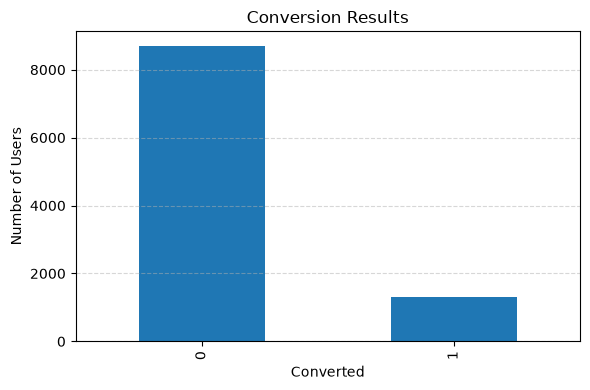

In [27]:
conversion_counts = df["Converted"].value_counts()

plt.figure(figsize=(6,4))
conversion_counts.plot(kind="bar")

plt.title("Conversion Results")
plt.xlabel("Converted")
plt.ylabel("Number of Users")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("../images/conversion_results.png")

plt.show()

In [14]:
conversion_rate = df.groupby("Group")["Converted"].mean() * 100

conversion_rate


Group
A    11.869140
B    14.237016
Name: Converted, dtype: float64

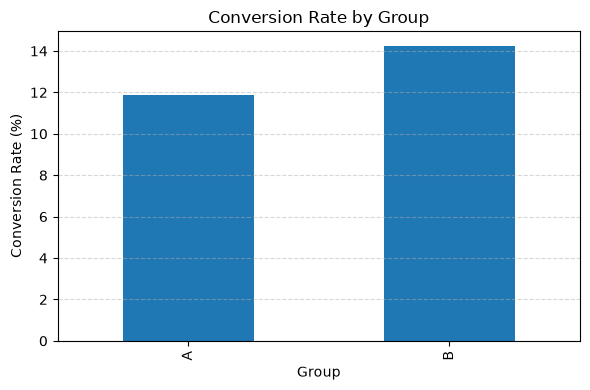

In [24]:
plt.figure(figsize=(6,4))

conversion_rate.plot(kind="bar")

plt.title("Conversion Rate by Group")
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("../images/conversion_rate.png")

plt.show()

In [16]:
difference = conversion_rate["B"] - conversion_rate["A"]

print(f"Difference in Conversion Rate: {difference:.2f}%")

Difference in Conversion Rate: 2.37%


In [17]:
successes = [
    df[df["Group"] == "A"]["Converted"].sum(),
    df[df["Group"] == "B"]["Converted"].sum()
]

observations = [
    len(df[df["Group"] == "A"]),
    len(df[df["Group"] == "B"])
]

print("Successes:", successes)
print("Observations:", observations)

Successes: [np.int64(595), np.int64(710)]
Observations: [5013, 4987]


In [18]:
z_stat, p_value = proportions_ztest(successes, observations)

print("Z-Statistic:", round(z_stat, 4))
print("P-Value:", round(p_value, 6))

Z-Statistic: -3.5147
P-Value: 0.00044


In [19]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference between the two groups.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no statistically significant difference between the two groups.")

Reject the Null Hypothesis
There is a statistically significant difference between the two groups.


In [20]:
conversion_rate = df.groupby("Group")["Converted"].mean() * 100

improvement = conversion_rate["B"] - conversion_rate["A"]

print(f"Conversion Rate (A): {conversion_rate['A']:.2f}%")
print(f"Conversion Rate (B): {conversion_rate['B']:.2f}%")
print(f"Improvement: {improvement:.2f}%")

Conversion Rate (A): 11.87%
Conversion Rate (B): 14.24%
Improvement: 2.37%


In [21]:
monthly_visitors = 1000000
average_order_value = 1200

additional_orders = monthly_visitors * (improvement / 100)
additional_revenue = additional_orders * average_order_value

print(f"Additional Orders per Month: {additional_orders:,.0f}")
print(f"Estimated Additional Revenue: ₹{additional_revenue:,.0f}")

Additional Orders per Month: 23,679
Estimated Additional Revenue: ₹28,414,512


In [22]:
if p_value < 0.05:
    print("Business Recommendation")
    print("- The new website design (Version B) performs better than Version A.")
    print("- The increase in conversion rate is statistically significant.")
    print("- It is recommended to roll out Version B to all users.")
else:
    print("Business Recommendation")
    print("- The observed improvement is not statistically significant.")
    print("- More data should be collected before making a decision.")

Business Recommendation
- The new website design (Version B) performs better than Version A.
- The increase in conversion rate is statistically significant.
- It is recommended to roll out Version B to all users.


In [23]:
from statsmodels.stats.proportion import confint_proportions_2indep

low, high = confint_proportions_2indep(
    successes[0],
    observations[0],
    successes[1],
    observations[1],
    method="wald"
)

print(f"95% Confidence Interval: ({low:.4f}, {high:.4f})")

95% Confidence Interval: (-0.0369, -0.0105)
